# Evoscope teaching notebook

This notebook uses the modular version of Evoscope to show how local regulatory rules generate multicellular spatial patterns.

## 1. Import the model

The key teaching objects are `Config`, `Evoscope`, and `grid_to_numpy`.

In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from evoscope import Config, Evoscope, grid_to_numpy
from evoscope.visualization import plot_grid_array, plot_genes, plot_clusters
from evoscope.io import save_global_gene_csv, save_cluster_gene_csv

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML

In [2]:
import evoscope
print(evoscope.__file__)

/home/lunan/Evoscope/evoscope_teaching_modules/evoscope_teaching/evoscope/__init__.py


## 2. Define a minimal world

Students can change these parameters and immediately observe how the simulation changes.

In [3]:
cfg = Config(
    width=60,
    height=40,
    initial_cells=30,
    initial_medium_nutrient=6.9,
    seed=42,
    verbose=False,
)


#sim = Evoscope(cfg)
#print(sim.summary_line())

## 3. Run the simulation

Each step updates sensing, regulation, energy, cell cycle, commitment, movement, division, attack/division, nutrient diffusion, and metrics.

In [4]:
sim = Evoscope(cfg)

frames = []

for _ in range(120):
    sim.step()
    frames.append(grid_to_numpy(sim).copy())


# Valori:
# -1 = empty
#  0 = undetermined
#  1-8 = committed clusters 0-7

colors = [
    "black",      # -1 empty
    "lightgray",  #  0 undetermined
    "red",        #  1 cluster 0
    "green",      #  2 cluster 1
    "gold",       #  3 cluster 2
    "blue",       #  4 cluster 3
    "magenta",    #  5 cluster 4
    "cyan",       #  6 cluster 5
    "white",      #  7 cluster 6
    "orange",     #  8 cluster 7
]

cmap = ListedColormap(colors)

bounds = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(15, 6))

im = ax.imshow(
    frames[0],
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

ax.axis("off")

def update(i):
    im.set_data(frames[i])
    ax.set_title(f"Evoscope - epoch {i + 1}")
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=100,
    blit=True,
)

import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="black", label="empty"),
    mpatches.Patch(color="lightgray", label="undetermined"),
    mpatches.Patch(color="red", label="cluster 0"),
    mpatches.Patch(color="green", label="cluster 1"),
    mpatches.Patch(color="gold", label="cluster 2"),
    mpatches.Patch(color="blue", label="cluster 3"),
    mpatches.Patch(color="magenta", label="cluster 4"),
    mpatches.Patch(color="cyan", label="cluster 5"),
    mpatches.Patch(color="white", label="cluster 6"),
    mpatches.Patch(color="orange", label="cluster 7"),
]

ax.legend(
    handles=legend_items,
    bbox_to_anchor=(1.05, 1),
    loc="lower right",
    borderaxespad=-12,
)
plt.close(fig)

HTML(anim.to_jshtml())

## 6. Plot global regulatory dynamics

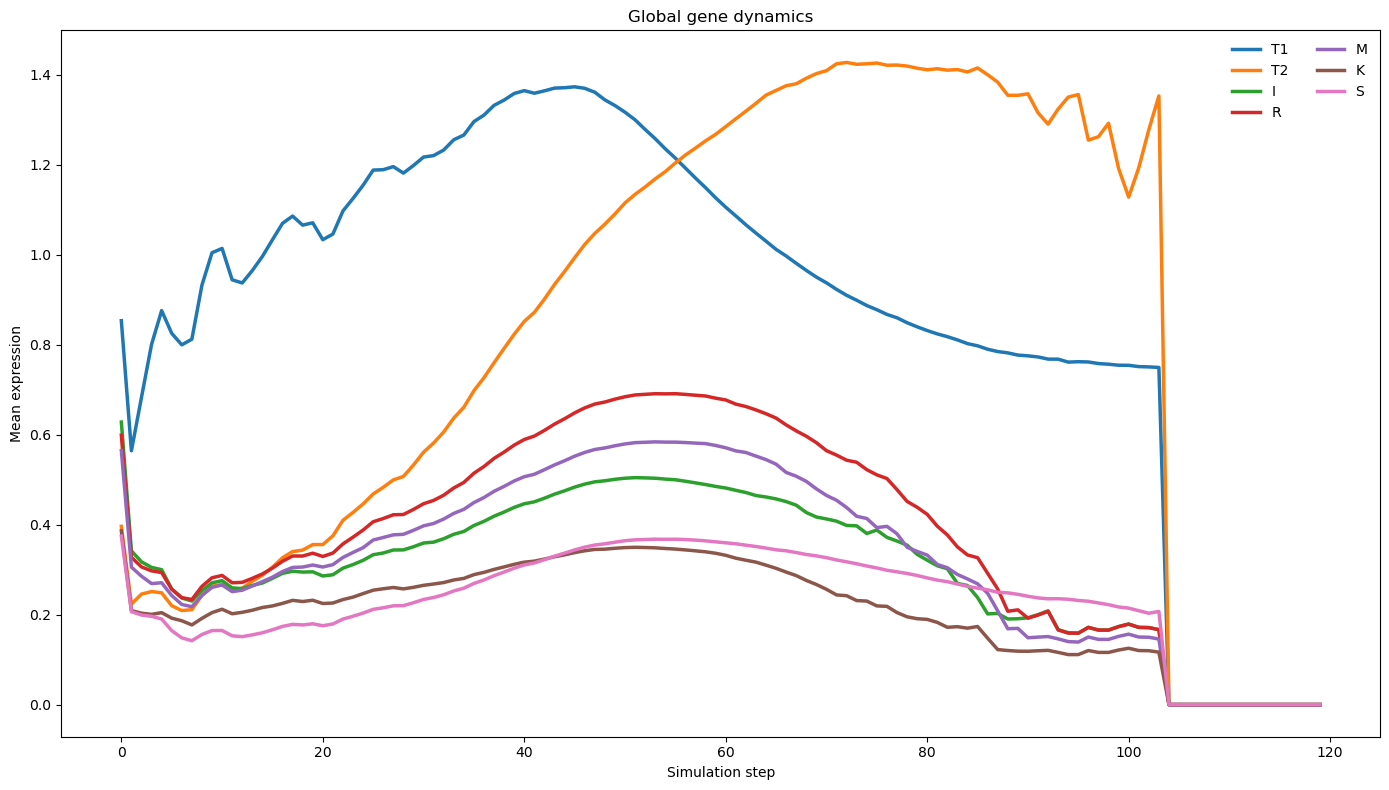

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Global gene dynamics'}, xlabel='Simulation step', ylabel='Mean expression'>)

In [5]:
plot_genes(sim)

## 7. Plot one gene by cluster

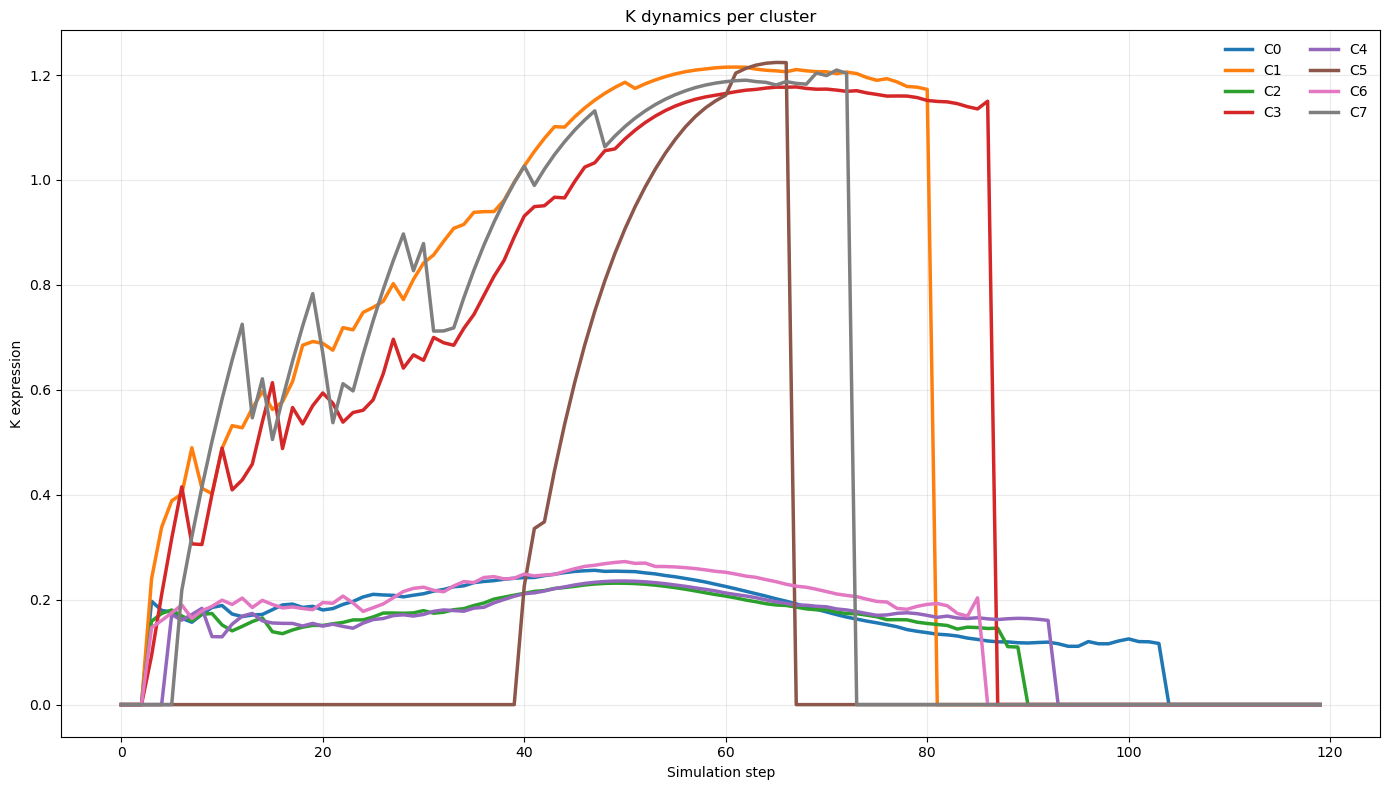

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'K dynamics per cluster'}, xlabel='Simulation step', ylabel='K expression'>)

In [6]:
plot_clusters(sim, gene="K")

In [9]:
save_global_gene_csv(sim, path="global_genes.csv")
save_cluster_gene_csv(sim, path="cluster_genes.csv")

## 8. Exercises

1. Increase `initial_medium_nutrient`. Does the final morphology become denser?
2. Increase `diffusion_rate`. Does nutrient smoothing reduce local heterogeneity?
3. Increase `h_bias_strength`. Do committed clusters become more behaviorally distinct?
4. Change `seed`. Which patterns are robust and which are stochastic?